
---

### Plan

  1. Je vais créer une stratégie avec un résultat de backtest parfait (SR > 2).    

  2. Pourquoi ça marche à tous les coups (en apparence).  

  3. Comment repérer "l'arnaque".     

  4. Comment s'en protéger.     


---

## Imports & Setup

In [1]:
from helpers import *
setup()

Setup OK


## Téléchargement BTC/USDT H4

Données Binance en chandeliers 4h, cachées en CSV local.

In [2]:
df = load_data()
df.head(3)

Chargement depuis le cache local...
Période : 2020-01-01 00:00:00 → 2026-01-01 00:00:00
Nombre de bougies H4 : 13,152


,open,high,low,close,volume
timestamp,,,,,
2020-01-01 00:00:00,7195.24,7245.00,7175.46,7225.01,2833.749180
2020-01-01 04:00:00,7225.00,7236.27,7199.11,7209.83,2061.295051
2020-01-01 08:00:00,7209.83,7237.73,7180.00,7197.20,3166.654361


In [3]:
df.tail(3)

,open,high,low,close,volume
timestamp,,,,,
2025-12-31 16:00:00,87953.97,88053.49,87400.41,87541.85,2936.14316
2025-12-31 20:00:00,87541.85,87879.04,87250.00,87648.22,1581.56113
2026-01-01 00:00:00,87648.21,88088.10,87632.74,87846.02,833.74412


## Split Train / Test (70/30)

Train : 2020-01-01 00:00:00 → 2024-03-14 08:00:00  (9,206 bougies)
Test  : 2024-03-14 12:00:00 → 2026-01-01 00:00:00  (3,946 bougies)


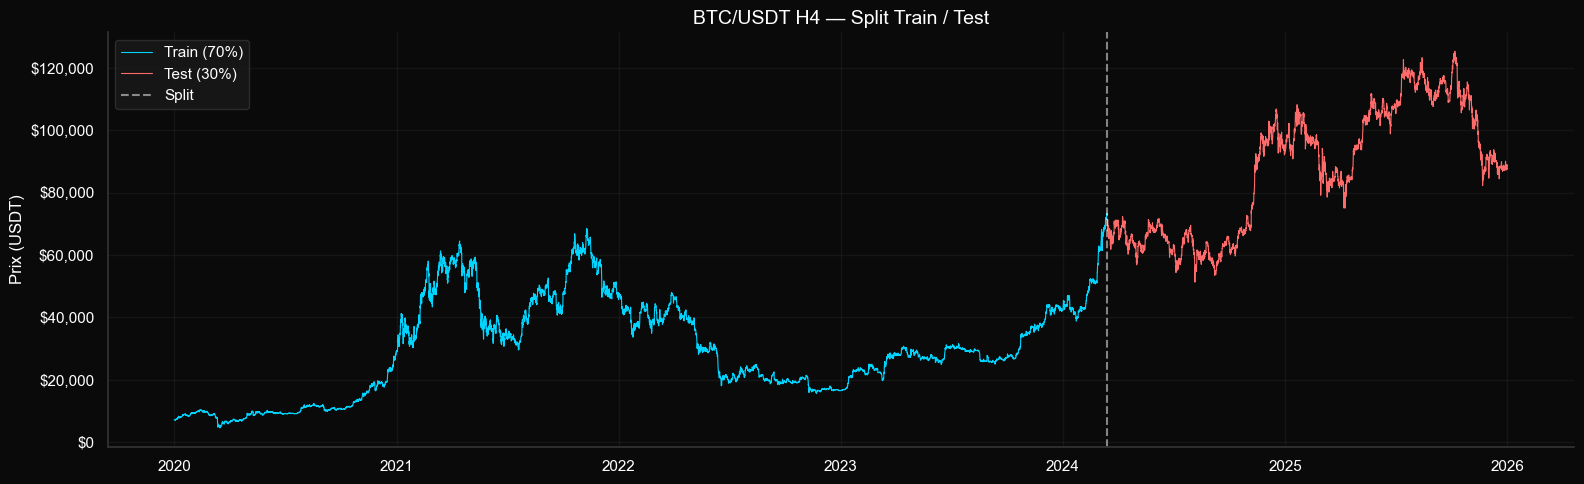

In [4]:
train, test = split_train_test(df)
close_train, close_test = train['close'], test['close']

plot_train_test_split(train, test)

---

## Définition de la stratégie — MA Crossover + TP/SL

4 paramètres :
- **Fast MA** / **Slow MA** : périodes des moyennes mobiles
- **Take Profit (%)** / **Stop Loss (%)**

**Règles :**
- **Long** : Fast MA croise au-dessus de Slow MA
- **Sortie** : croisement inverse, OU TP touché, OU SL touché

---

## Grande Grille : ~100,000 combinaisons / backtests

On teste **massivement** :
- 529 paires MA × 192 combos TP/SL = **~100,000 backtests**

In [5]:
# --- Parametres Grande Grille ---
fast_windows_large = list(range(10, 101, 4))      # 23 valeurs : 10 a 98
slow_windows_large = list(range(100, 1001, 40))    # 23 valeurs : 100 a 980
tp_values_large = list(range(5, 51, 3))            # 16 valeurs : 5 a 50
sl_values_large = list(range(5, 51, 4))            # 12 valeurs : 5 a 49

print_grid_info(fast_windows_large, slow_windows_large, tp_values_large, sl_values_large)

Fast MA windows  : 23 valeurs (10 à 98)
Slow MA windows  : 23 valeurs (100 à 980)
MA pairs (f < s) : 529
TP values        : 16 valeurs
SL values        : 12 valeurs
TP/SL combos     : 192
Total combos     : 101,568


101568

In [6]:
pf_lg, tp_sl_combos_lg, n_ma_lg = run_grid_backtest(
    close_train, fast_windows_large, slow_windows_large, tp_values_large, sl_values_large
)

Paires MA générées : 529
Colonnes totales : 101,568
Backtest terminé — 101,568 stratégies évaluées


In [7]:
# ATTENTION : Peut prendre du temps (et de la RAM) selon votre machine...
is_lg = get_best_is_results(pf_lg)
print_best_is(is_lg, 'GRANDE GRILLE')

GRANDE GRILLE — Meilleure stratégie IN-SAMPLE
Colonne          : (np.int64(84), np.int64(42), np.int64(420))
Sharpe Ratio     : 2.111
Total Return     : 524.81%
Max Drawdown     : -26.82%


---

## Moment de vérité : Out-of-Sample (Grande Grille)

La meilleure strategie IS testee sur des donnees qu'elle n'a **jamais vues**.

In [8]:
fast_w, slow_w, best_tp_lg, best_sl_lg = extract_best_params(is_lg['best_col'], tp_sl_combos_lg)

Meilleure config :
  Fast MA  = 42
  Slow MA  = 420
  TP       = 26%
  SL       = 5%


In [9]:
pf_oos_lg = run_oos_backtest(close_test, fast_w, slow_w, best_tp_lg, best_sl_lg)
oos_lg = print_is_vs_oos(is_lg, pf_oos_lg, 'GRANDE GRILLE')

GRANDE GRILLE — Comparaison IS vs OOS
Métrique                In-Sample  Out-of-Sample
------------------------------------------------------------
Sharpe Ratio                2.111         -0.378
Total Return              524.81%        -14.46%
Max Drawdown              -26.82%        -25.90%


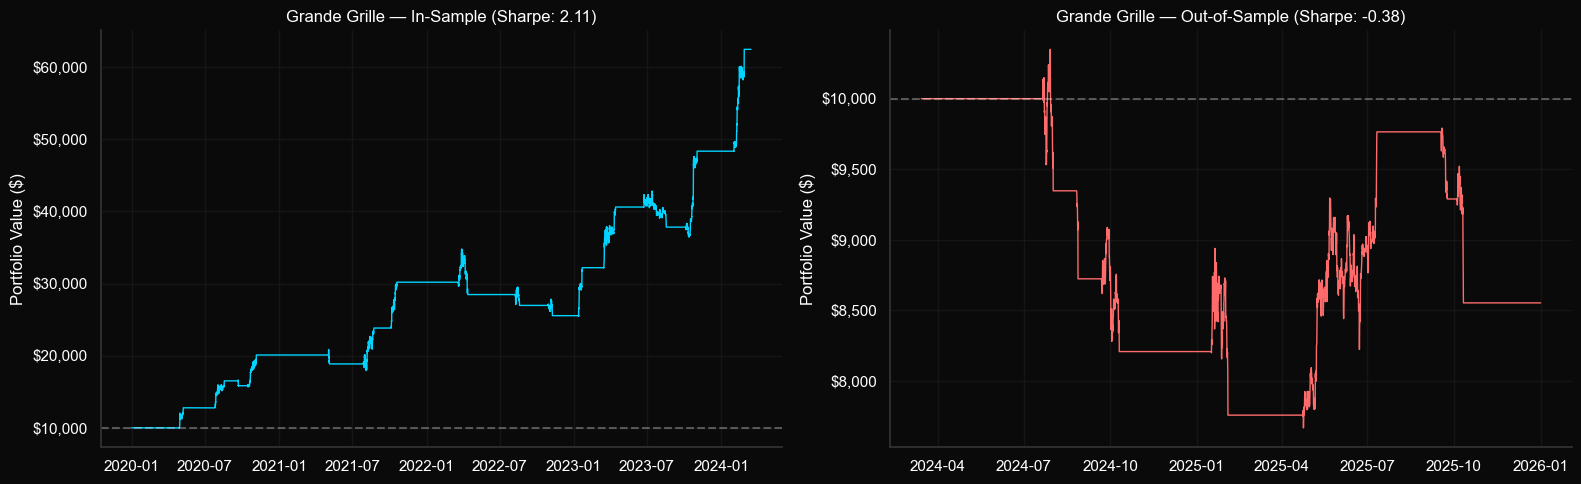

In [10]:
plot_equity_is_oos(
    pf_lg[is_lg['best_col']], pf_oos_lg,
    is_lg['best_sharpe'], pf_oos_lg.sharpe_ratio(),
    title_prefix='Grande Grille —'
)

---

## Petite Grille : 36 combinaisons

Même exercice, grille **beaucoup plus petite** :
- 6 paires MA × 6 combos TP/SL = **36 backtests**

Moins on teste, moins on risque de trouver un faux positif.

In [11]:
# --- Parametres Petite Grille ---
fast_windows_small = [20, 50]
slow_windows_small = [200, 500, 1000]
tp_values_small = [10, 25, 50]
sl_values_small = [10, 30]

print_grid_info(fast_windows_small, slow_windows_small, tp_values_small, sl_values_small)

Fast MA windows  : 2 valeurs (20 à 50)
Slow MA windows  : 3 valeurs (200 à 1000)
MA pairs (f < s) : 6
TP values        : 3 valeurs
SL values        : 2 valeurs
TP/SL combos     : 6
Total combos     : 36


36

In [12]:
pf_sm, tp_sl_combos_sm, n_ma_sm = run_grid_backtest(
    close_train, fast_windows_small, slow_windows_small, tp_values_small, sl_values_small
)

Paires MA générées : 6
Colonnes totales : 36
Backtest terminé — 36 stratégies évaluées


In [13]:
is_sm = get_best_is_results(pf_sm)
print_best_is(is_sm, 'PETITE GRILLE')

PETITE GRILLE — Meilleure stratégie IN-SAMPLE
Colonne          : (np.int64(4), np.int64(20), np.int64(200))
Sharpe Ratio     : 1.479
Total Return     : 578.25%
Max Drawdown     : -47.01%


In [14]:
fast_w_sm, slow_w_sm, best_tp_sm, best_sl_sm = extract_best_params(is_sm['best_col'], tp_sl_combos_sm)

pf_oos_sm = run_oos_backtest(close_test, fast_w_sm, slow_w_sm, best_tp_sm, best_sl_sm)
oos_sm = print_is_vs_oos(is_sm, pf_oos_sm, 'PETITE GRILLE')

Meilleure config :
  Fast MA  = 20
  Slow MA  = 200
  TP       = 50%
  SL       = 10%
PETITE GRILLE — Comparaison IS vs OOS
Métrique                In-Sample  Out-of-Sample
------------------------------------------------------------
Sharpe Ratio                1.479          0.736
Total Return              578.25%         33.32%
Max Drawdown              -47.01%        -22.85%


## Comparaison Grande vs Petite Grille

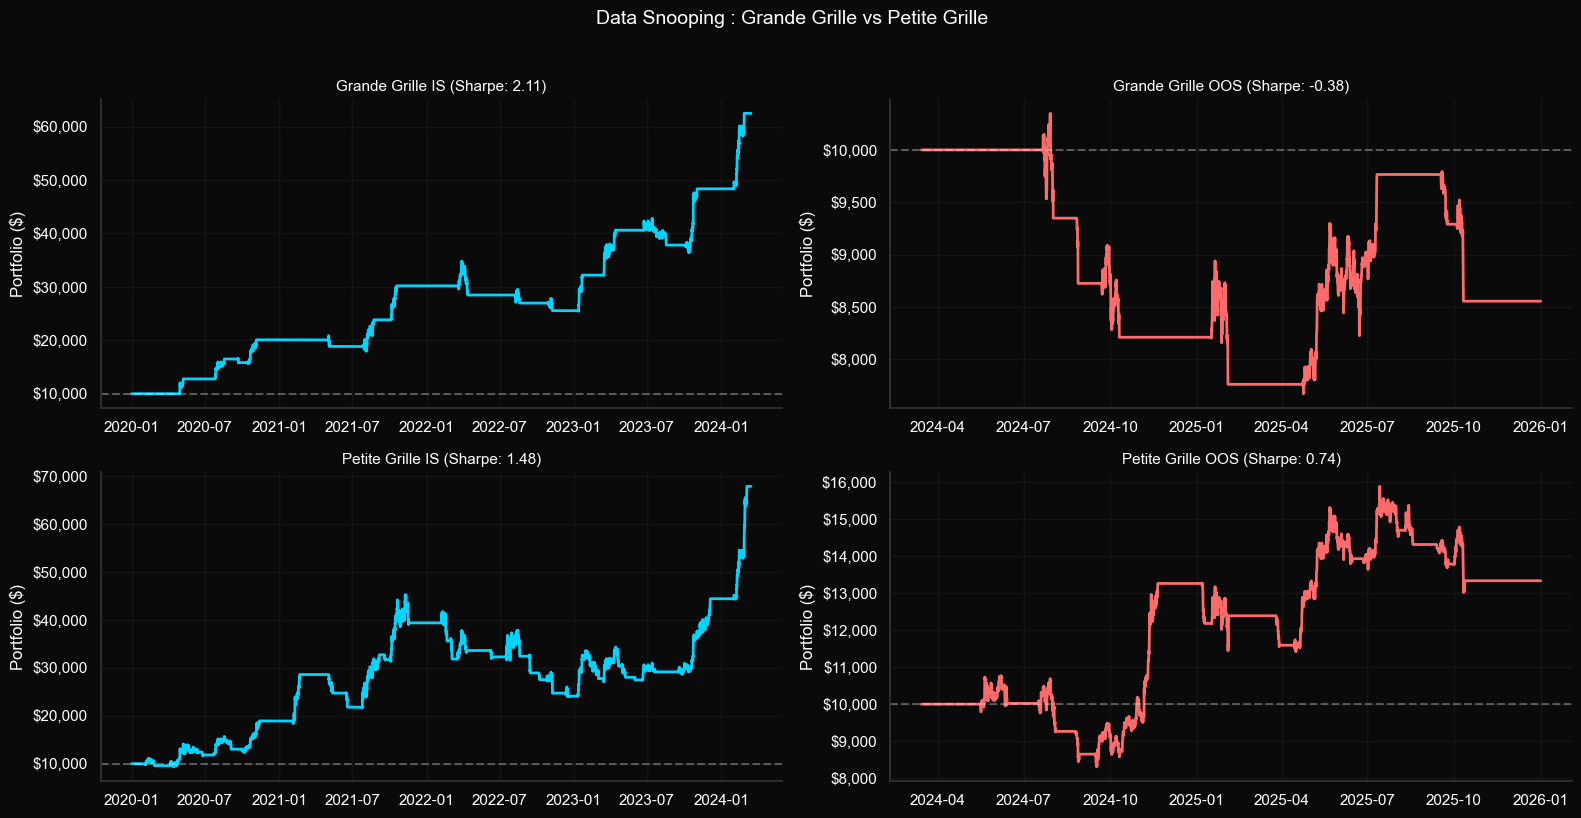

In [15]:
plot_comparison_2x2(
    pf_lg[is_lg['best_col']], pf_oos_lg, is_lg['best_sharpe'], pf_oos_lg.sharpe_ratio(),
    pf_sm[is_sm['best_col']], pf_oos_sm, is_sm['best_sharpe'], pf_oos_sm.sharpe_ratio()
)

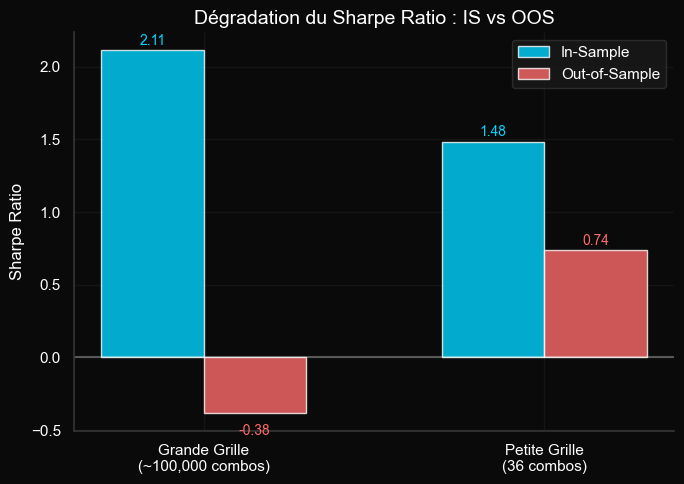

In [16]:
plot_sharpe_degradation_bar(
    is_lg['best_sharpe'], pf_oos_lg.sharpe_ratio(),
    is_sm['best_sharpe'], pf_oos_sm.sharpe_ratio()
)

---

## Regarder la distribution, pas juste le meilleur
On ne regarde jamais **que** la meilleure stratégie. Il faut regarder **toute la grille** pour comprendre si le "best" est un signal ou du bruit.

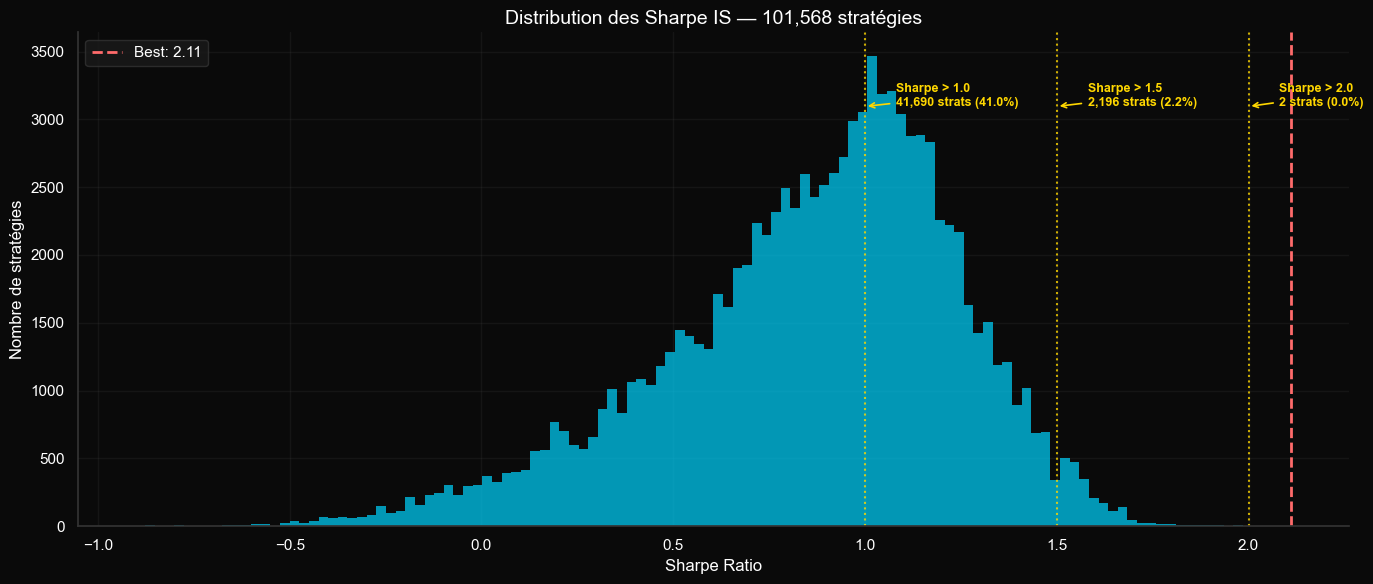


Sur 101,568 stratégies testées :
  Sharpe > 1.0 : 41,690 stratégies (41.0%)
  Sharpe > 1.5 : 2,196 stratégies (2.2%)
  Sharpe > 2.0 : 2 stratégies (0.0%)


In [17]:
plot_sharpe_distribution(is_lg['sharpes'], is_lg['best_sharpe'])

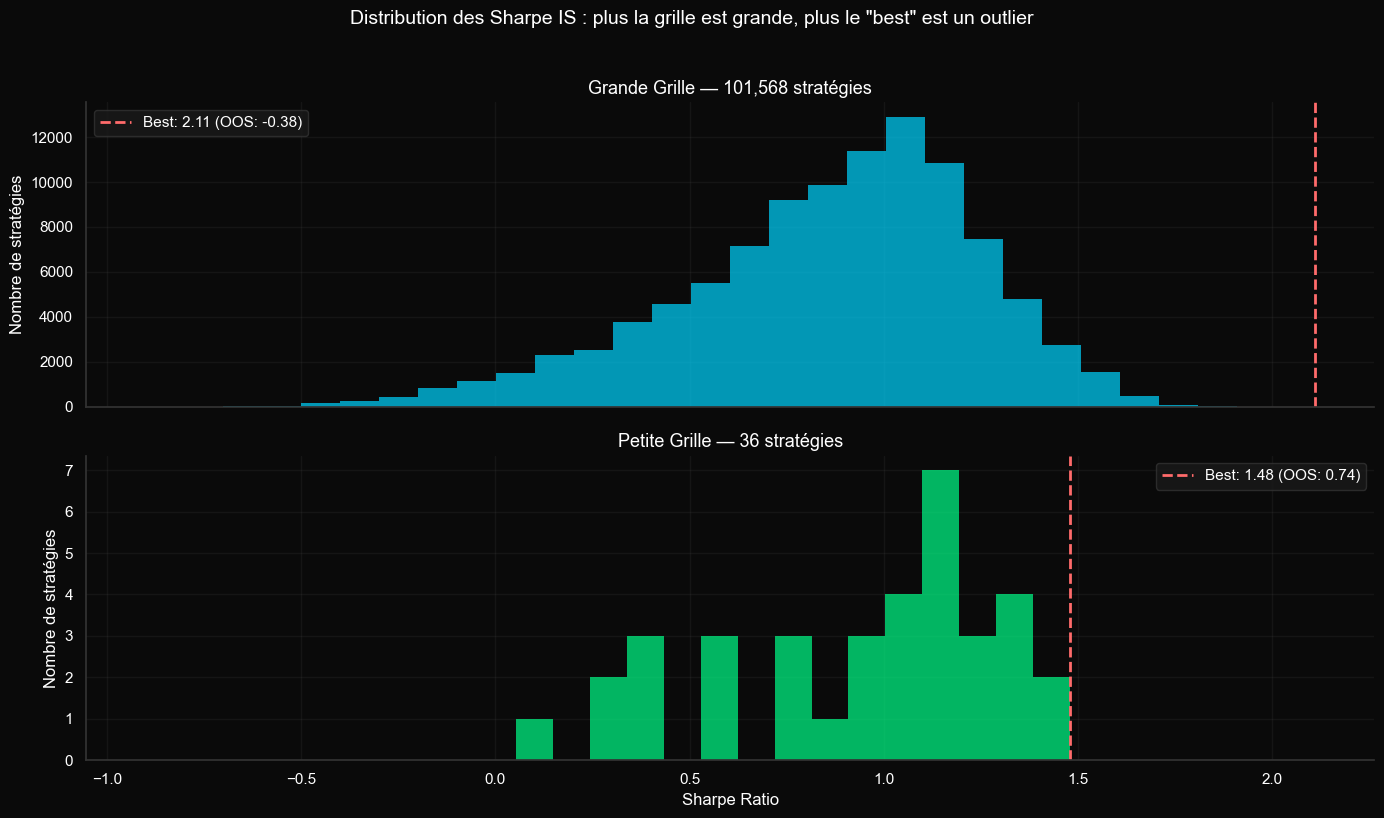

Grande Grille : 101,568 stratégies → best IS = 2.11, écart au médiane = 1.19
Petite Grille : 36 stratégies  → best IS = 1.48, écart au médiane = 0.45


In [18]:
plot_distributions_comparison(
    is_lg['sharpes'], is_lg['best_sharpe'], pf_oos_lg.sharpe_ratio(),
    is_sm['sharpes'], is_sm['best_sharpe'], pf_oos_sm.sharpe_ratio()
)

---

## Test de sensibilité ±10% sur le "best"

Si la meilleure stratégie est vraiment robuste, une variation de **seulement 10%** sur ses paramètres ne devrait pas affecter sa performance.
On varie **un paramètre à la fois**, les autres restent fixes.

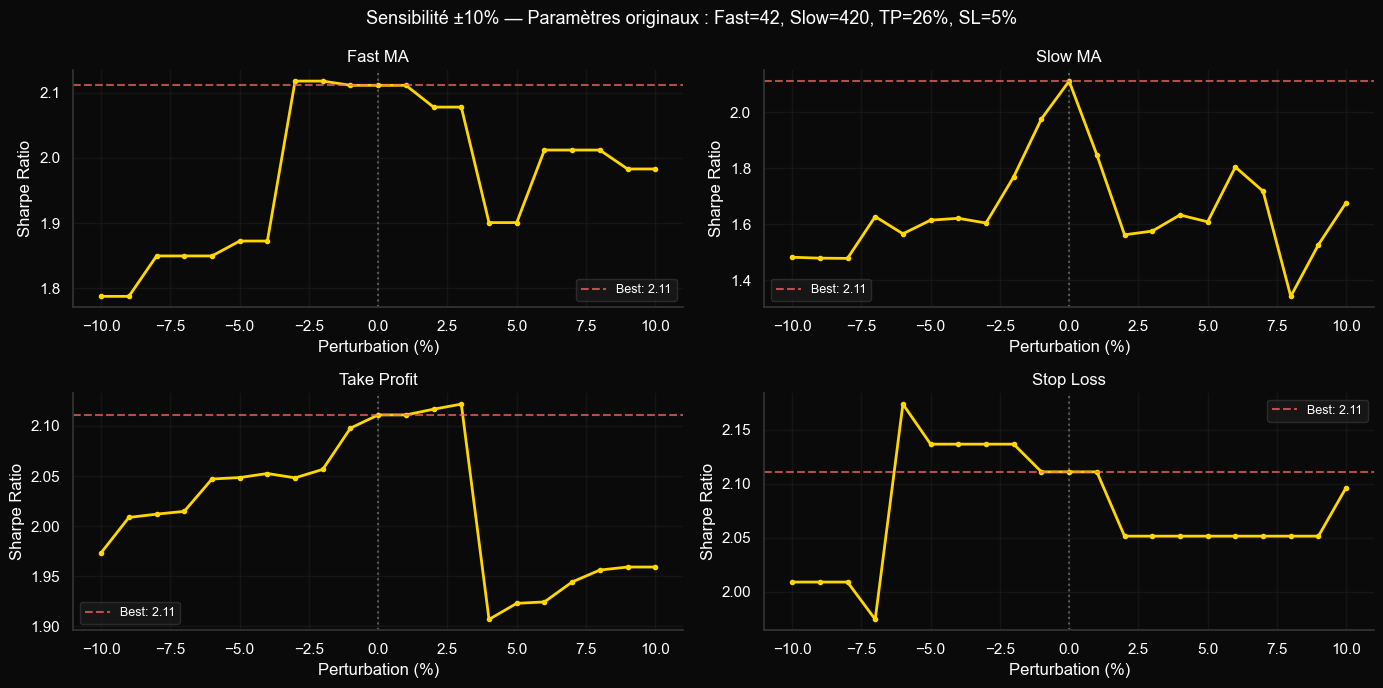

Paramètres originaux : Fast=42, Slow=420, TP=26%, SL=5%
Sharpe original : 2.111

  Fast MA      : min=1.788, max=2.117, écart=0.330
  Slow MA      : min=1.343, max=2.111, écart=0.768
  Take Profit  : min=1.907, max=2.122, écart=0.215
  Stop Loss    : min=1.975, max=2.174, écart=0.199


In [19]:
sensitivity = run_sensitivity(close_train, fast_w, slow_w, best_tp_lg, best_sl_lg)
plot_sensitivity(sensitivity, is_lg['best_sharpe'], fast_w, slow_w, best_tp_lg, best_sl_lg)
print_sensitivity_stats(sensitivity, is_lg['best_sharpe'], fast_w, slow_w, best_tp_lg, best_sl_lg)

---
## D'où vient le problème ? Les tests multiples

Le mécanisme est purement **statistique** et n'a rien à voir avec le trading en soi.

### L'analogie du dé

- Lancer **1 dé** et faire un 6 : probabilité = **16.7%**
- Lancer **100 dés** et obtenir **au moins un** 6 : probabilité ≈ **100%**

C'est exactement ce qu'on fait avec nos 101,568 backtests : on lance 100,000 dés et on montre fièrement le meilleur résultat.

Même sur des données **purement aléatoires**, une stratégie a une chance de paraître "bonne" par pur hasard.     
Plus on teste de combinaisons, plus on a de chances de tomber sur un faux positif.

> Avec 36 tests, le Sharpe IS est modeste et **tient en OOS**.    
> Avec 101,568 tests, le Sharpe IS est impressionnant mais **s'effondre en OOS** > c'était du bruit.

---

## Pourquoi les gens font du data snooping ?


**1. Ignorance du problème des tests multiples**.    

**2. Biais de confirmation**.    

**3. Conflits d'intérêts**
- Les **vendeurs de formations** :       
"Ma stratégie fait +300% par an !"* — backtest optimisé sur 100K combinaisons, zéro mention du nombre de backtests...    

- Les **vendeurs de robots/bots** :    
Ils montrent l'equity curve parfaite du backtest, jamais les résultats en live. (ou plus subtil, une partie des comptes pas tout...)      

- Les **fonds d'investissements** :     
Ils publient la performance de leur meilleur fonds et ferment discrètement ceux qui ont sous-performé.      

- Les **chercheurs/académiques** :      
Pression à publier des résultats "significatifs" → on teste jusqu'à trouver un p-value < 0.05 (p-hacking).

---

## Conclusion


In [20]:
summary_table(is_lg, oos_lg, pf_lg.sharpe_ratio().shape[0], is_sm, oos_sm, pf_sm.sharpe_ratio().shape[0])

,Métrique,Grande Grille,Petite Grille
0,Nombre de combos,"101,568",36
1,Best Sharpe IS,2.111,1.479
2,Sharpe OOS,-0.378,0.736
3,Dégradation Sharpe,-117.9%,-50.2%
4,Total Return IS,524.81%,578.25%
5,Total Return OOS,-14.46%,33.32%
6,Max DD IS,-26.82%,-47.01%
7,Max DD OOS,-25.90%,-22.85%



Attention :      
> **Backtest sans précision sur le nombre d'essais réalisés est caduque** (Soit 99,9% ...)

### Pour éviter ça

- **Limiter le nombre de combinaisons testées**.      
- **Regarder la distribution et le TOP, pas juste le meilleur**.  
- **Tracer le nombre de tests que vous faites**.   
- **Toujours valider en Out-of-Sample**.   
- **Hypothèse économique AVANT de tester**.  
- **Tester la sensibilité aux paramètres**.     
- **Corrections statistiques (Ex. DSR)**.  


> **Pour aller plus loin :**
> - Veritasium — [Is Most Published Research Wrong?](https://www.youtube.com/watch?v=42QuXLucH3Q) (video, 13 min)
> - Bailey et al. (2014) — [Pseudo-Mathematics and Financial Charlatanism](https://www.ams.org/notices/201405/rnoti-p458.pdf) (trading)
> - Bailey & Lopez de Prado (2014) — [The Deflated Sharpe Ratio](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2460551) (finance quantitative)